**Business Understanding**

**Problem Statement**: Predict which telecom customers are at high risk of churning.

**Business Objective**: Reduce churn, increase retention, and increase customer lifetime value (CLV).

**Success Metrics**: Recall, ROC-AUC, Revenue Saved.
Target Variable: TARGET = "Churn"

In [ ]:
#Environment Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [ ]:
#Data Loading
df = pd.read_csv('dataset.csv')
display(df.head())

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [ ]:
#Audit Report
audit_report = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isnull().sum(),
    "missing_pct": round(df.isnull().mean()*100,2),
    "unique": df.nunique(),
    "duplicates": df.duplicated().sum()
})

display(audit_report)

,dtype,missing,missing_pct,unique,duplicates
State,object,0,0.0,51,0
Account length,int64,0,0.0,212,0
Area code,int64,0,0.0,3,0
International plan,object,0,0.0,2,0
Voice mail plan,object,0,0.0,2,0
Number vmail messages,int64,0,0.0,46,0
Total day minutes,float64,0,0.0,1667,0
Total day calls,int64,0,0.0,119,0
Total day charge,float64,0,0.0,1667,0
Total eve minutes,float64,0,0.0,1611,0


In [ ]:
#Data Dictionary
data_dictionary = {
    "State": "Customer's state/location",
    "Account length": "Number of days customer has been associated with the telecom company",
    "Area code": "Customer's telecom area code",
    "International plan": "Whether customer has subscribed to international calling plan (Yes/No)",
    "Voice mail plan": "Whether customer has subscribed to voicemail service (Yes/No)",
    "Number vmail messages": "Total number of voicemail messages",
    "Total day minutes": "Total daytime call minutes used by customer",
    "Total day calls": "Total number of daytime calls",
    "Total day charge": "Charges incurred during daytime usage",
    "Total eve minutes": "Total evening call minutes used by customer",
    "Total eve calls": "Total number of evening calls",
    "Total eve charge": "Charges incurred during evening usage",
    "Total night minutes": "Total nighttime call minutes used by customer",
    "Total night calls": "Total number of nighttime calls",
    "Total night charge": "Charges incurred during nighttime usage",
    "Total intl minutes": "Total international call minutes used",
    "Total intl calls": "Total number of international calls",
    "Total intl charge": "Charges incurred from international calls",
    "Customer service calls": "Number of calls made to customer support",
    "Churn": "Target variable indicating whether customer left the company (True/False)"
}

data_dict_df = pd.DataFrame(
    list(data_dictionary.items()),
    columns=["Column Name", "Business Meaning"]
)

display(data_dict_df)

,Column Name,Business Meaning
0,State,Customer's state/location
1,Account length,Number of days customer has been associated wi...
2,Area code,Customer's telecom area code
3,International plan,Whether customer has subscribed to internation...
4,Voice mail plan,Whether customer has subscribed to voicemail s...
5,Number vmail messages,Total number of voicemail messages
6,Total day minutes,Total daytime call minutes used by customer
7,Total day calls,Total number of daytime calls
8,Total day charge,Charges incurred during daytime usage
9,Total eve minutes,Total evening call minutes used by customer


In [ ]:
#Missing Value Handling
# Mean (balanced data) - Median(inbalanced data) - Drop
#Duplicate Handling
#drop_duplicates

In [ ]:
#Business KPI Layer
df['Total Charges'] = df['Total day charge'] + df['Total eve charge'] + df['Total night charge'] + df['Total intl charge']
avg_revenue_per_customer = df['Total Charges'].mean()
clv = avg_revenue_per_customer * 12
print(f"Churn Rate: {df['Churn'].mean() * 100:.2f}%")
print(f"Estimated Annual CLV: ₹{clv:.2f}")

Churn Rate: 14.49%
Estimated Annual CLV: ₹713.40


In [ ]:
kpis = pd.DataFrame({
    "Metric":[
        "Customers",
        "Churn %",
        "Avg Revenue",
        "Annual CLV"
    ],
    "Value":[
        len(df),
        round(df["Churn"].mean()*100,2),
        round(avg_revenue_per_customer,2),
        round(clv,2)
    ]
})
print(kpis)

        Metric    Value
0    Customers  3333.00
1      Churn %    14.49
2  Avg Revenue    59.45
3   Annual CLV   713.40


In [ ]:
#Univariate, Categorical & Skewness Analysis

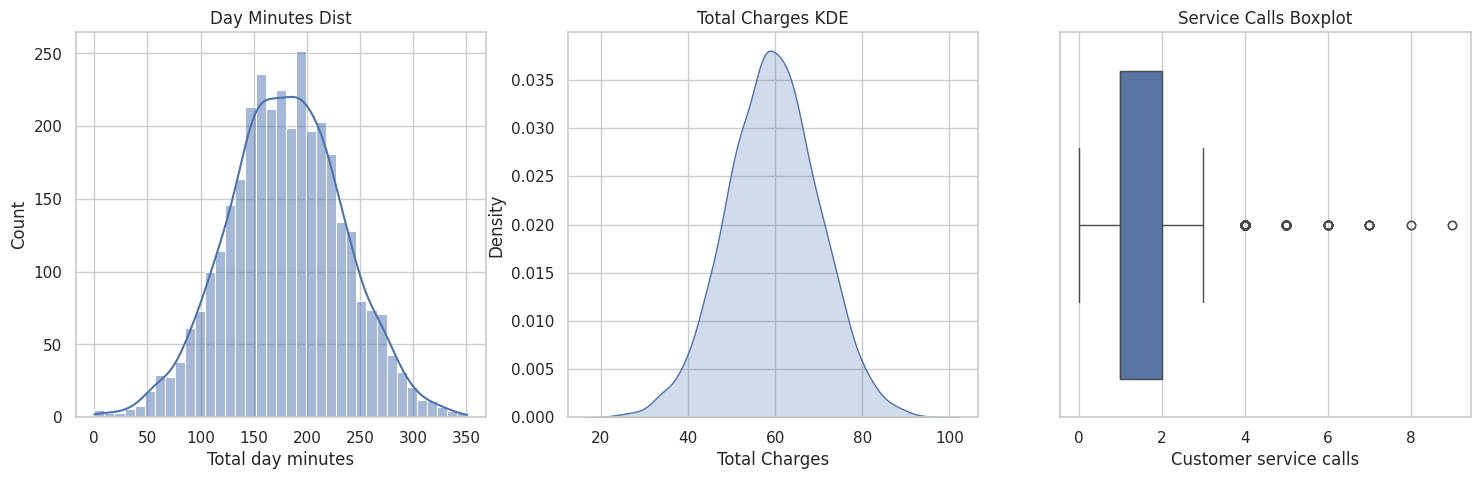

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Univariate: Distribution, KDE, Boxplot
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['Total day minutes'], kde=True, ax=ax[0]).set_title('Day Minutes Dist')
sns.kdeplot(df['Total Charges'], fill=True, ax=ax[1]).set_title('Total Charges KDE')
sns.boxplot(x=df['Customer service calls'], ax=ax[2]).set_title('Service Calls Boxplot')
plt.show()

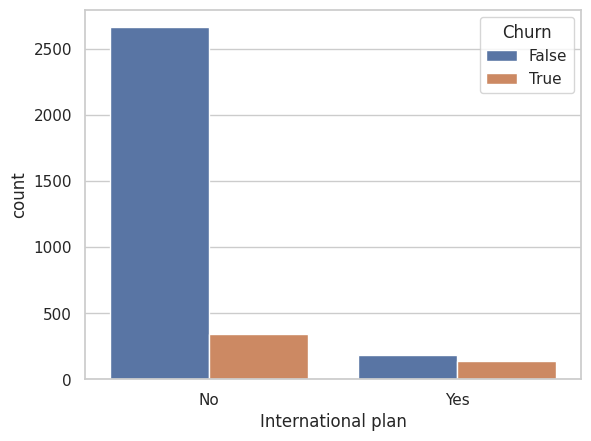

In [ ]:
# Categorical
sns.countplot(x='International plan', hue='Churn', data=df)
plt.show()

In [ ]:
# Skewness
print(df.select_dtypes(include='number').skew().sort_values(ascending=False))

Total intl calls          1.321478
Number vmail messages     1.264824
Area code                 1.126823
Customer service calls    1.091359
Account length            0.096606
Total night calls         0.032500
Total night minutes       0.008921
Total night charge        0.008886
Total eve charge         -0.023858
Total eve minutes        -0.023877
Total day minutes        -0.029077
Total day charge         -0.029083
Total Charges            -0.034791
Total eve calls          -0.055563
Total day calls          -0.111787
Total intl minutes       -0.245136
Total intl charge        -0.245287
dtype: float64


In [ ]:
#We need to identify exactly which raw features drive churn before building any models

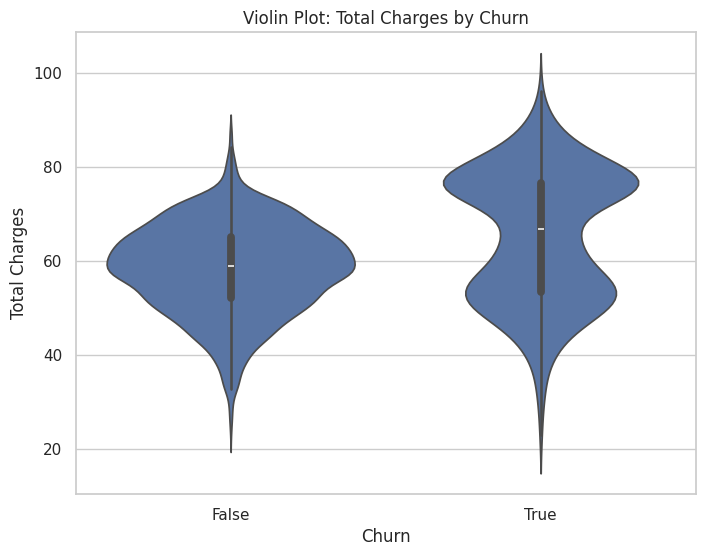

In [ ]:
#Standard Bivariate
fig, axes = plt.subplots(figsize=(8, 6)) # Create a single figure and axes
sns.violinplot(x='Churn', y='Total Charges', data=df, ax=axes)
axes.set_title("Violin Plot: Total Charges by Churn")
plt.show()

In [ ]:
# Explicit top correlations
print("Top Features Correlated with Churn")

# Ensure 'Churn' column is numerical (0 or 1)
df['Churn'] = df['Churn'].astype(int)

# Calculate correlation matrix for all numerical columns in df, including 'Churn'
correlation_with_churn = df.corr(numeric_only=True)['Churn'].sort_values(ascending=False).head(5)
print(correlation_with_churn)

Top Features Correlated with Churn
Churn                     1.000000
Total Charges             0.231549
Customer service calls    0.208750
Total day minutes         0.205151
Total day charge          0.205151
Name: Churn, dtype: float64


In [ ]:
# Churn by State BEFORE encoding
state_churn = df.groupby('State')['Churn'].mean().sort_values(ascending=False)
display(state_churn.head().round(3))

,Churn
State,
CA,0.265
NJ,0.265
TX,0.250
MD,0.243
SC,0.233


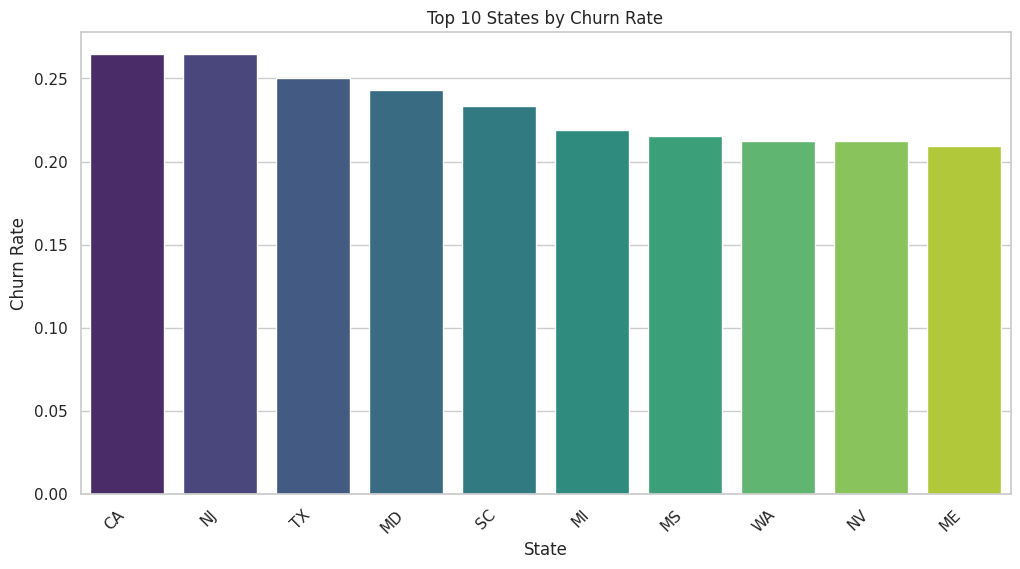

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=state_churn.head(10).index, y=state_churn.head(10).values, palette='viridis')
plt.title('Top 10 States by Churn Rate')
plt.xlabel('State')
plt.ylabel('Churn Rate')
plt.xticks(rotation=45, ha='right')
plt.show()

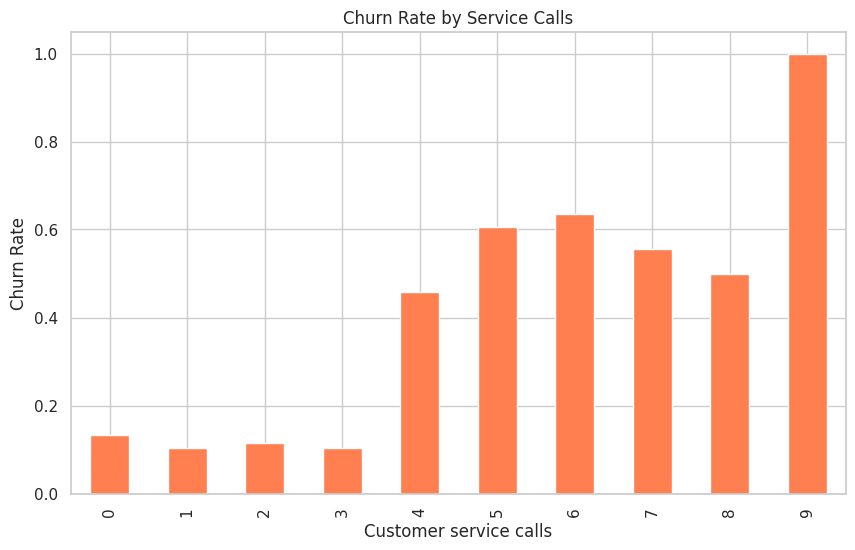

In [ ]:
#Churn Rate by Service Calls
churn_by_calls = (df.groupby("Customer service calls")["Churn"].mean())
fig, ax = plt.subplots(figsize=(10, 6))
churn_by_calls.plot(kind="bar", color='coral', ax=ax)
ax.set_title("Churn Rate by Service Calls")
ax.set_ylabel("Churn Rate")
plt.show()

In [ ]:
#Multivariate Analysis

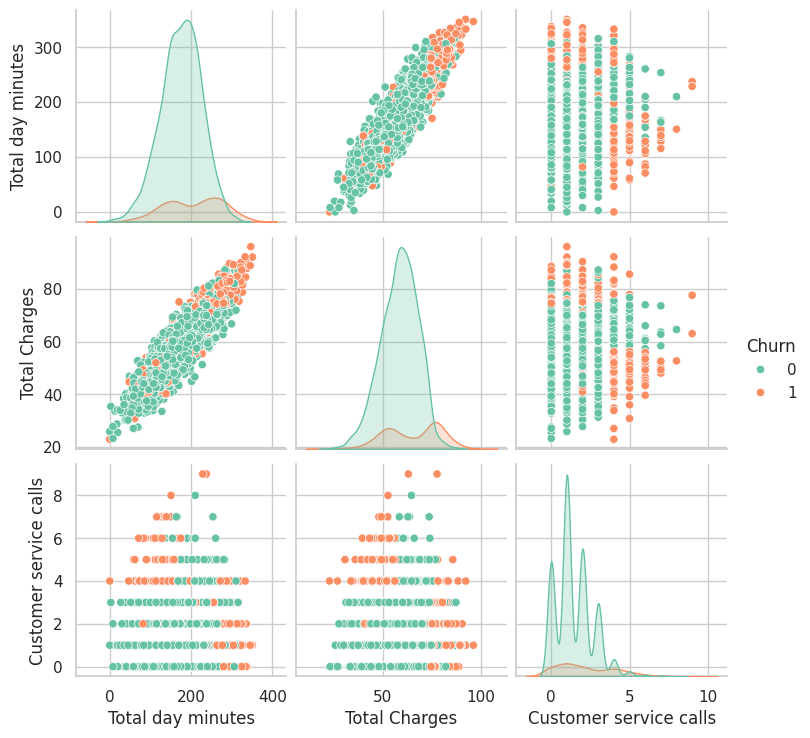

In [ ]:
#Pairplot
sns.pairplot(
    df[["Total day minutes", "Total Charges", "Customer service calls", "Churn"]],
    hue="Churn",
    palette="Set2"
)
plt.show()

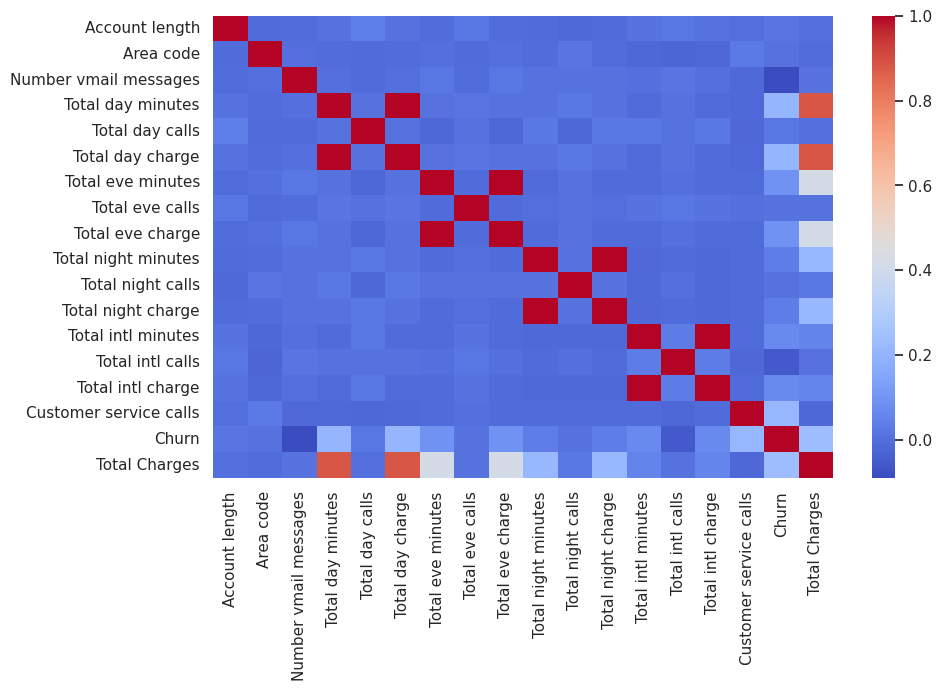

Churn,0,1
International plan,,
No,0.89,0.11
Yes,0.58,0.42


In [ ]:
#Correlation Heatmap & Crosstab
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.show()
display(pd.crosstab(df['International plan'], df['Churn'], normalize='index').round(2))

In [ ]:
#Outlier Handling for All Numerical Columns

In [ ]:
 numeric_cols = df.select_dtypes(include=np.number).columns

print("Applying IQR-based clipping to numerical columns:")
for col in numeric_cols:
    if col == 'Churn': # Skip the target variable if it's numerical (boolean converted to int)
        continue
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    initial_min = df[col].min()
    initial_max = df[col].max()
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    final_min = df[col].min()
    final_max = df[col].max()

    if initial_min != final_min or initial_max != final_max:
        print(f"  - Column '{col}': Outliers clipped. Min changed from {initial_min:.2f} to {final_min:.2f}, Max changed from {initial_max:.2f} to {final_max:.2f}")
    else:
        print(f"  - Column '{col}': No outliers found or already within bounds.")

Applying IQR-based clipping to numerical columns:
  - Column 'Account length': Outliers clipped. Min changed from 1.00 to 1.00, Max changed from 243.00 to 206.50
  - Column 'Area code': No outliers found or already within bounds.
  - Column 'Number vmail messages': Outliers clipped. Min changed from 0.00 to 0.00, Max changed from 51.00 to 50.00
  - Column 'Total day minutes': Outliers clipped. Min changed from 0.00 to 34.65, Max changed from 350.80 to 325.45
  - Column 'Total day calls': Outliers clipped. Min changed from 0.00 to 46.50, Max changed from 165.00 to 154.50
  - Column 'Total day charge': Outliers clipped. Min changed from 0.00 to 5.89, Max changed from 59.64 to 55.33
  - Column 'Total eve minutes': Outliers clipped. Min changed from 0.00 to 63.55, Max changed from 363.70 to 338.35
  - Column 'Total eve calls': Outliers clipped. Min changed from 0.00 to 46.50, Max changed from 170.00 to 154.50
  - Column 'Total eve charge': Outliers clipped. Min changed from 0.00 to 5.40, M

In [ ]:
#We cap (winsorize) outliers instead of deleting them to avoid losing valuable customer data.
#Visualizing the transformation proves it worked

In [ ]:
#Algorithms learn better from explicit signals. We use pd.qcut to create smart business segments

In [ ]:
#Feature Engineering
df['Total_Usage'] = df['Total day minutes'] + df['Total eve minutes'] + df['Total night minutes'] + df['Total intl minutes']
df['Service_Stress'] = df['Customer service calls'] / (df['Account length'] + 1)

# Using pd.qcut as requested (Expert Review Addition)
df['Revenue_Segment'] = pd.qcut(df['Total Charges'], q=3, labels=['Low', 'Medium', 'High'])

In [ ]:
print(df.columns)

Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn', 'Total Charges', 'Total_Usage', 'Service_Stress',
       'Revenue_Segment'],
      dtype='object')


In [ ]:
#Machine learning models only read numbers.
#We must track our matrix shape to ensure one-hot encoding doesn't cause a dimensional explosion

In [ ]:
le = LabelEncoder()
df['International plan'] = le.fit_transform(df['International plan'])
df['Voice mail plan'] = le.fit_transform(df['Voice mail plan'])
df['Churn'] = le.fit_transform(df['Churn'])
df = pd.get_dummies(df, columns=['State', 'Revenue_Segment'], drop_first=True, dtype=int)

In [ ]:
#Feature Selection

In [ ]:
# Automated High Correlation Detection
corr_matrix = df.corr(numeric_only=True).abs()
high_corr = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.95:
            high_corr.add(corr_matrix.columns[i])

print(f"Dropping highly correlated data-driven columns: {high_corr}")
df.drop(columns=high_corr, inplace=True)

Dropping highly correlated data-driven columns: {'Number vmail messages', 'Total night charge', 'Total day charge', 'Total intl charge', 'Total eve charge'}


In [ ]:
area_churn = (
    df.groupby("Area code")["Churn"]
      .mean()
)

print(area_churn)

Area code
408    0.145585
415    0.142598
510    0.148810
Name: Churn, dtype: float64


In [ ]:
# Drop Area Code
df.drop('Area code', axis=1, inplace=True, errors='ignore')
print("Note: 'Area code' was dropped because it acts as an arbitrary ID and has no predictive power for churn.")

Note: 'Area code' was dropped because it acts as an arbitrary ID and has no predictive power for churn.


In [ ]:
#Train-Test Split & Scaling Comparison

In [ ]:
X = df.drop(['Churn'], axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
# Compare Scalers
scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()
scaler_robust = RobustScaler()

In [ ]:
X_train_std = pd.DataFrame(scaler_std.fit_transform(X_train), columns=X_train.columns)
X_test_std = pd.DataFrame(scaler_std.transform(X_test), columns=X_test.columns)

In [ ]:
X_train_mm = pd.DataFrame(scaler_minmax.fit_transform(X_train), columns=X_train.columns)
X_train_rob = pd.DataFrame(scaler_robust.fit_transform(X_train), columns=X_train.columns)

In [ ]:
print("StandardScaler Mean:", X_train_std['Total day minutes'].mean().round(2))
print("MinMaxScaler Min-Max:", X_train_mm['Total day minutes'].min(), "-", X_train_mm['Total day minutes'].max())

StandardScaler Mean: -0.0
MinMaxScaler Min-Max: 0.0 - 1.0


In [ ]:
#Class Distribution Visualization
#If we don't know the class imbalance, we won't understand why our baseline Accuracy is misleading

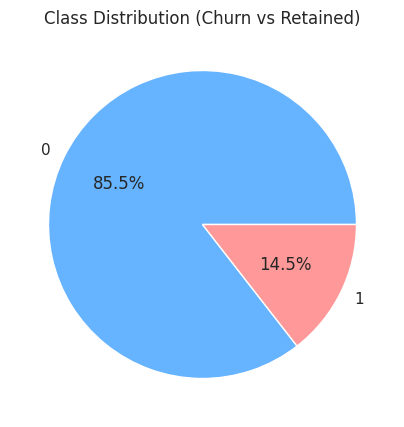

In [ ]:
# Visualizing Imbalance
plt.figure(figsize=(5,5))
y_train.value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
plt.title("Class Distribution (Churn vs Retained)")
plt.ylabel("")
plt.show()

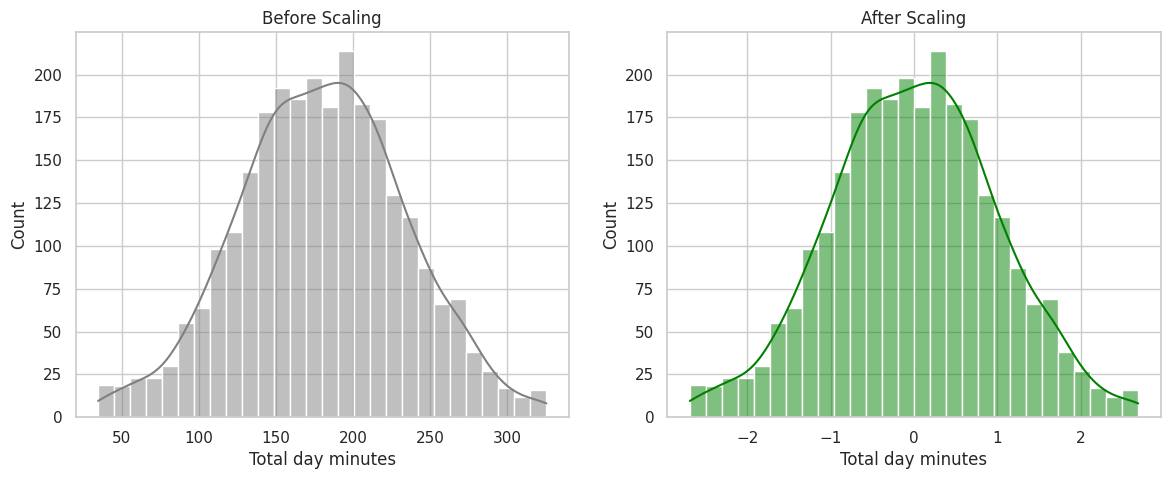

In [ ]:
# Feature Distribution Before vs After Scaling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(X_train["Total day minutes"], ax=axes[0], kde=True, color='gray').set_title("Before Scaling")
sns.histplot(X_train_std["Total day minutes"], ax=axes[1], kde=True, color='green').set_title("After Scaling")
plt.show()

In [ ]:
#Models, Evaluation & Confusion Matrix

In [ ]:
# Train Logistic & Decision Tree
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_std, y_train)
pred_lr, prob_lr = lr.predict(X_test_std), lr.predict_proba(X_test_std)[:, 1]
print(f"Logistic Regression -> Recall: {recall_score(y_test, pred_lr):.3f}")

Logistic Regression -> Recall: 0.701


In [ ]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
dt.fit(X_train_std, y_train)
pred_dt, prob_dt = dt.predict(X_test_std), dt.predict_proba(X_test_std)[:, 1]
print(f"Decision Tree -> Recall: {recall_score(y_test, pred_dt):.3f}")

Decision Tree -> Recall: 0.887


In [ ]:
# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train_std, y_train)

pred_rf = rf.predict(X_test_std)
prob_rf = rf.predict_proba(X_test_std)[:, 1]

print(f"Random Forest -> Recall: {recall_score(y_test, pred_rf):.3f}")

Random Forest -> Recall: 0.639


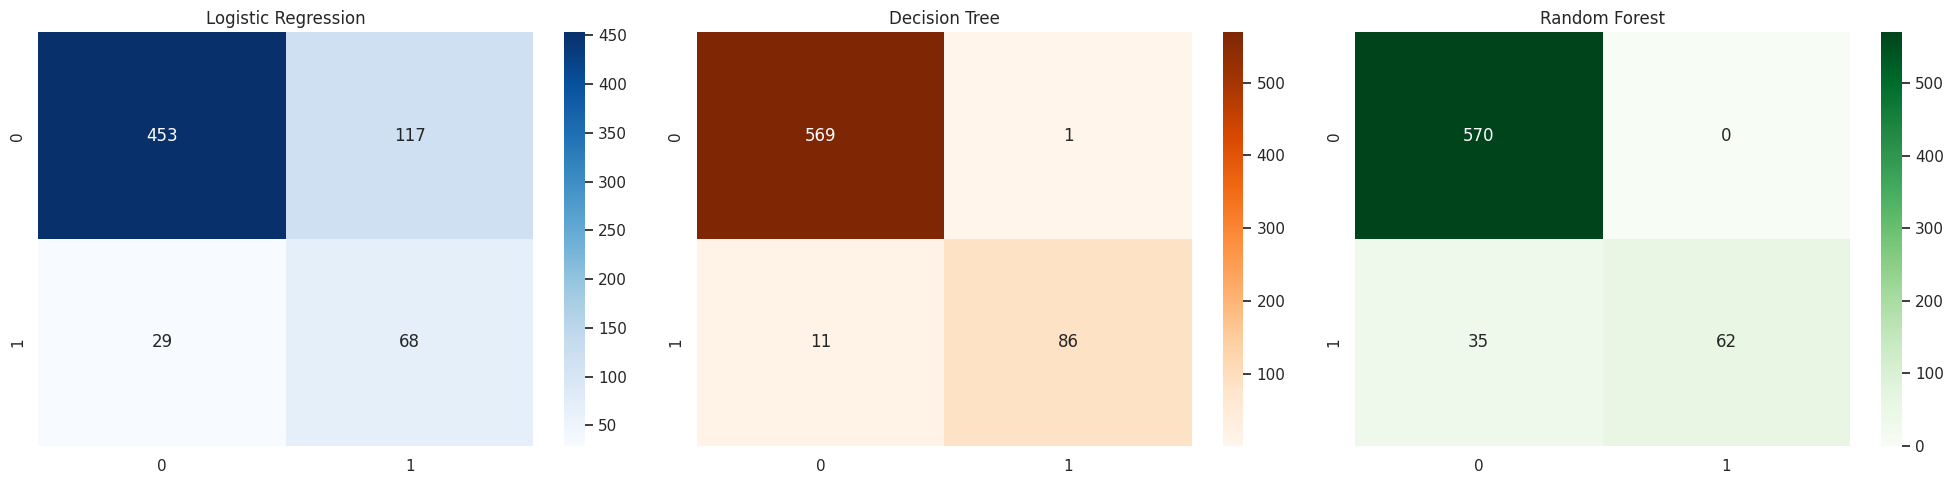

In [ ]:
# Confusion Matrix Heatmap
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Logistic Regression
sns.heatmap(
    confusion_matrix(y_test, pred_lr),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title("Logistic Regression")

# Decision Tree
sns.heatmap(
    confusion_matrix(y_test, pred_dt),
    annot=True,
    fmt='d',
    cmap='Oranges',
    ax=axes[1]
)
axes[1].set_title("Decision Tree")

# Random Forest
sns.heatmap(
    confusion_matrix(y_test, pred_rf),
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[2]
)
axes[2].set_title("Random Forest")

plt.tight_layout()
plt.show()

**ACCURACY**

100 CUSTOMERS - MODEL PREDICTION
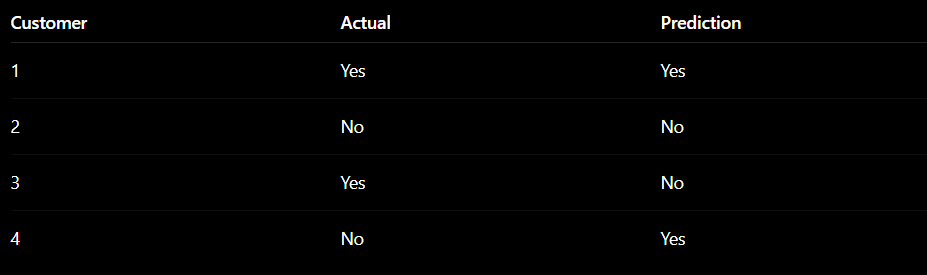

ACCURACY - OUT OF TOTAL PREDICTIONS HOW MANY ARE RIGHT

Correct Predictions / Total Predictions

**INBALANCED DATA - PRECISION AND RECALL**

PRECISION - Out of all predicted positives, how many actually were positive

Prediction : 100 Customers will Churn but in Reality only 70 did

High Precision = Less False Positive

Precision = TP / (TP + FP)


---


RECALL - Out of all actual positives, how many were identified

100 Customers were to be Churn , Prediction idetified only 70

**Conservative / Aggressive Model**

**BALANCE - F1 SCORE**

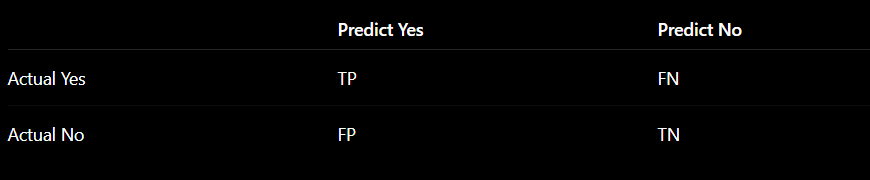

In [ ]:
#ROC Curve, Dashboard, Feature Importance & Persistence

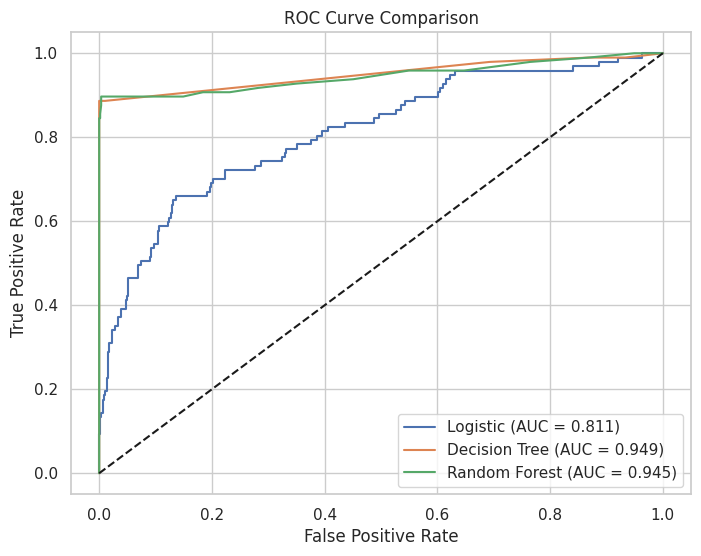

In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic (AUC = {roc_auc_score(y_test, prob_lr):.3f})'
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f'Decision Tree (AUC = {roc_auc_score(y_test, prob_dt):.3f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {roc_auc_score(y_test, prob_rf):.3f})'
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

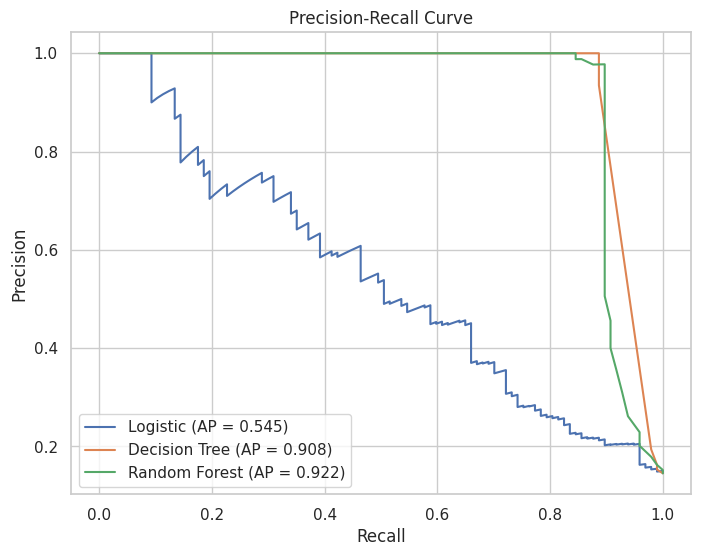

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Precision-Recall values
precision_lr, recall_lr, _ = precision_recall_curve(y_test, prob_lr)
precision_dt, recall_dt, _ = precision_recall_curve(y_test, prob_dt)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, prob_rf)

plt.figure(figsize=(8,6))

plt.plot(
    recall_lr,
    precision_lr,
    label=f'Logistic (AP = {average_precision_score(y_test, prob_lr):.3f})'
)

plt.plot(
    recall_dt,
    precision_dt,
    label=f'Decision Tree (AP = {average_precision_score(y_test, prob_dt):.3f})'
)

plt.plot(
    recall_rf,
    precision_rf,
    label=f'Random Forest (AP = {average_precision_score(y_test, prob_rf):.3f})'
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend()

plt.show()

How well the model separates the Positive class from the Negative class across all possible thresholds.

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, pred_rf)
    ],
    "Precision": [
        precision_score(y_test, pred_lr),
        precision_score(y_test, pred_dt),
        precision_score(y_test, pred_rf)
    ],
    "Recall": [
        recall_score(y_test, pred_lr),
        recall_score(y_test, pred_dt),
        recall_score(y_test, pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, pred_lr),
        f1_score(y_test, pred_dt),
        f1_score(y_test, pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, prob_lr),
        roc_auc_score(y_test, prob_dt),
        roc_auc_score(y_test, prob_rf)
    ]
})

comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.781,0.368,0.701,0.482,0.811
1,Decision Tree,0.982,0.989,0.887,0.935,0.949
2,Random Forest,0.948,1.000,0.639,0.780,0.945


,Importance
Total Charges,0.157026
Customer service calls,0.093923
Total_Usage,0.092100
Total day minutes,0.090389
International plan,0.085303
Service_Stress,0.048672
Total intl minutes,0.044831
Total eve minutes,0.043407
Total night minutes,0.039064
Account length,0.036357


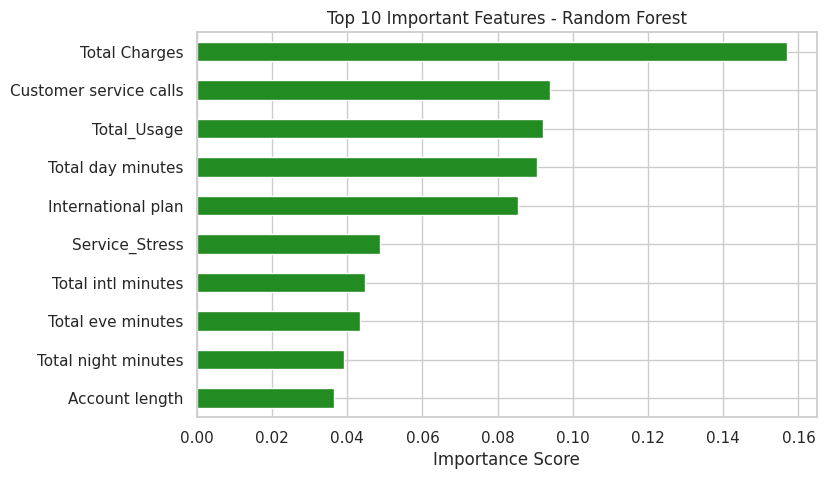

In [ ]:
# Feature Importance - Random Forest
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)
display(
    pd.DataFrame(feature_importance, columns=["Importance"]).head(10)
)
plt.figure(figsize=(8,5))
feature_importance.head(10).plot(
    kind="barh",
    color="forestgreen"
)
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance Score")
plt.show()

# Model Selection

We trained and evaluated three classification models:

- Logistic Regression
- Decision Tree
- Random Forest

Each model was assessed using multiple evaluation metrics including:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Precision-Recall Curve

Rather than selecting a model solely based on accuracy, the final model should align with the business objective.

Since our business problem focuses on identifying customers likely to churn, minimizing False Negatives is more important than simply maximizing overall accuracy.

Therefore, Recall becomes the primary evaluation metric.

The next section compares all trained models and selects the most suitable model for deployment.

In [ ]:
model_selection = comparison.copy()

model_selection = model_selection.sort_values(
    by="Recall",
    ascending=False
)

display(model_selection)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Decision Tree,0.982009,0.988506,0.886598,0.934783,0.949349
0,Logistic Regression,0.781109,0.367568,0.701031,0.482270,0.810761
2,Random Forest,0.947526,1.000000,0.639175,0.779874,0.945433


In [ ]:
best_model_name = model_selection.iloc[0]["Model"]

print(f"Selected Model for Deployment : {best_model_name}")

Selected Model for Deployment : Decision Tree


# Hyperparameter Tuning

Until now, we have trained machine learning models using manually selected values such as:

- n_estimators = 100
- max_depth = 10
- k = 5

But an important question arises:

**How do we know these values are actually the best?**

The answer is:

We don't.

These values are called **Hyperparameters**.

Instead of manually guessing them, we use Hyperparameter Tuning techniques to automatically search for the best combination.

Hyperparameter tuning helps us improve:

- Accuracy
- Precision
- Recall
- Generalization
- Model Stability

In this section we will learn:

• Parameters vs Hyperparameters

• Grid Search

• Random Search

• Choosing the Best Model

# Parameters vs Hyperparameters

Machine Learning models contain two different types of values.

## Parameters

These are values that the model learns automatically from the training data.

Examples:

- Weights
- Bias
- Decision boundaries

The programmer never manually sets these values.

---------------------------------------

## Hyperparameters

These are values decided before training starts.

Examples:

- Number of Trees
- Maximum Depth
- Learning Rate
- Number of Neighbors
- Kernel Type

The programmer chooses these values.

Hyperparameter tuning automates this selection process.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Baseline Decision Tree
baseline_dt = DecisionTreeClassifier(random_state=42)

baseline_dt.fit(X_train, y_train)

baseline_pred = baseline_dt.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)

print(f"Baseline Accuracy : {baseline_accuracy:.4f}")

Baseline Accuracy : 0.9625


In [ ]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [None, "sqrt", "log2"]
}

param_grid

{'criterion': ['gini', 'entropy'],
 'max_depth': [3, 5, 10, 15, None],
 'min_samples_split': [2, 5, 10],
 'min_samples_leaf': [1, 2, 4],
 'max_features': [None, 'sqrt', 'log2']}

# Grid Search

Grid Search is an exhaustive search technique.

It trains the model using every possible combination of hyperparameters.

The model with the best Cross Validation score is selected.

Although Grid Search is computationally expensive,

it guarantees that every specified combination is evaluated.

In [ ]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, 15, None],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [ ]:
print("Best Parameters")
print(grid_search.best_params_)

print("\nBest Cross Validation Score")
print(round(grid_search.best_score_,4))

Best Parameters
{'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2}

Best Cross Validation Score
0.9756


In [ ]:
#Tuned Decision Tree
best_dt = grid_search.best_estimator_
pred_tuned = best_dt.predict(X_test)
tuned_accuracy = accuracy_score(y_test, pred_tuned)

print("Test Accuracy :", round(tuned_accuracy,4))

Test Accuracy : 0.982


# Comparing Baseline vs Tuned Model

Hyperparameter tuning should improve the model's ability to generalize.

Rather than relying on manually selected values,

we now compare:

- Baseline Model
- Tuned Model

to determine whether tuning provided measurable improvement.

In [ ]:
tuning_comparison = pd.DataFrame({

    "Model":[
        "Baseline Decision Tree",
        "Tuned Decision Tree"
    ],

    "Accuracy":[
        baseline_accuracy,
        tuned_accuracy
    ]
})

tuning_comparison

,Model,Accuracy
0,Baseline Decision Tree,0.962519
1,Tuned Decision Tree,0.982009


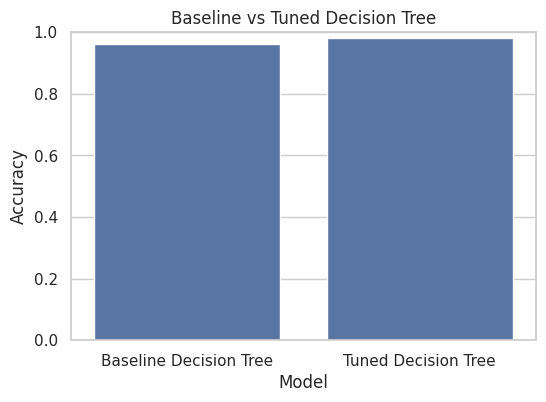

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=tuning_comparison,
    x="Model",
    y="Accuracy"
)
plt.title("Baseline vs Tuned Decision Tree")
plt.ylim(0,1)
plt.show()

# Limitations of Grid Search

Grid Search evaluates every possible combination.

While this ensures a thorough search,

it also makes Grid Search computationally expensive for large search spaces.

For models with many hyperparameters,

training time may become very high.

To solve this problem,

we use Randomized Search.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [3, 5, 10, 15, None],
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10]},
                   random_state=42, scoring='accuracy')

In [ ]:
print("Best Parameters")
print(random_search.best_params_)

print("\nBest Cross Validation Score")
print(round(random_search.best_score_,4))

Best Parameters
{'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 5, 'criterion': 'entropy'}

Best Cross Validation Score
0.9737


# Grid Search vs Random Search

Grid Search

• Evaluates every possible combination

• Higher computational cost

• Better for small search spaces

---------------------------------------

Random Search

• Evaluates only randomly selected combinations

• Much faster

• Preferred for large search spaces

In modern machine learning projects,

Random Search is often used as a practical alternative to Grid Search.

In [ ]:
best_random_dt = random_search.best_estimator_
pred_random = best_random_dt.predict(X_test)
random_accuracy = accuracy_score(y_test, pred_random)

print("Random Search Test Accuracy :", round(random_accuracy,4))

Random Search Test Accuracy : 0.9835


In [ ]:
search_comparison = pd.DataFrame({

    "Model":[
        "Baseline DT",
        "Grid Search DT",
        "Random Search DT"
    ],

    "Accuracy":[
        baseline_accuracy,
        tuned_accuracy,
        random_accuracy
    ]
})

search_comparison

,Model,Accuracy
0,Baseline DT,0.962519
1,Grid Search DT,0.982009
2,Random Search DT,0.983508


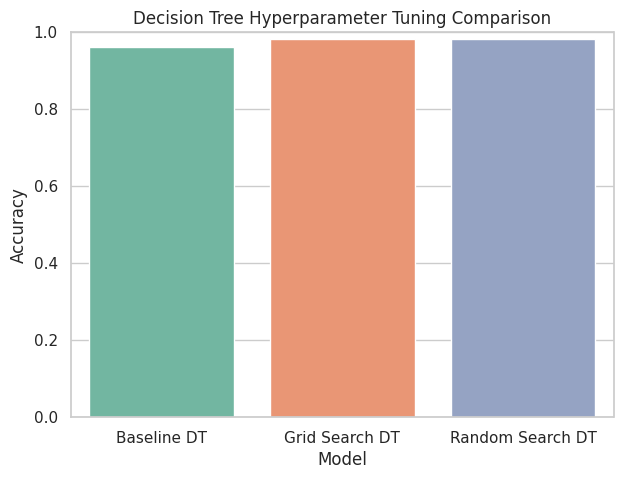

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=search_comparison,
    x="Model",
    y="Accuracy",
    palette="Set2"
)

plt.title("Decision Tree Hyperparameter Tuning Comparison")
plt.ylim(0,1)
plt.show()

# Visualizing the Final Decision Tree

After selecting and tuning the Decision Tree model, we can visualize its learned decision-making process.

Each internal node represents a decision based on a feature.

The colored leaf nodes represent the final prediction.

Tree visualization helps us understand how the model reaches a prediction and improves model interpretability.

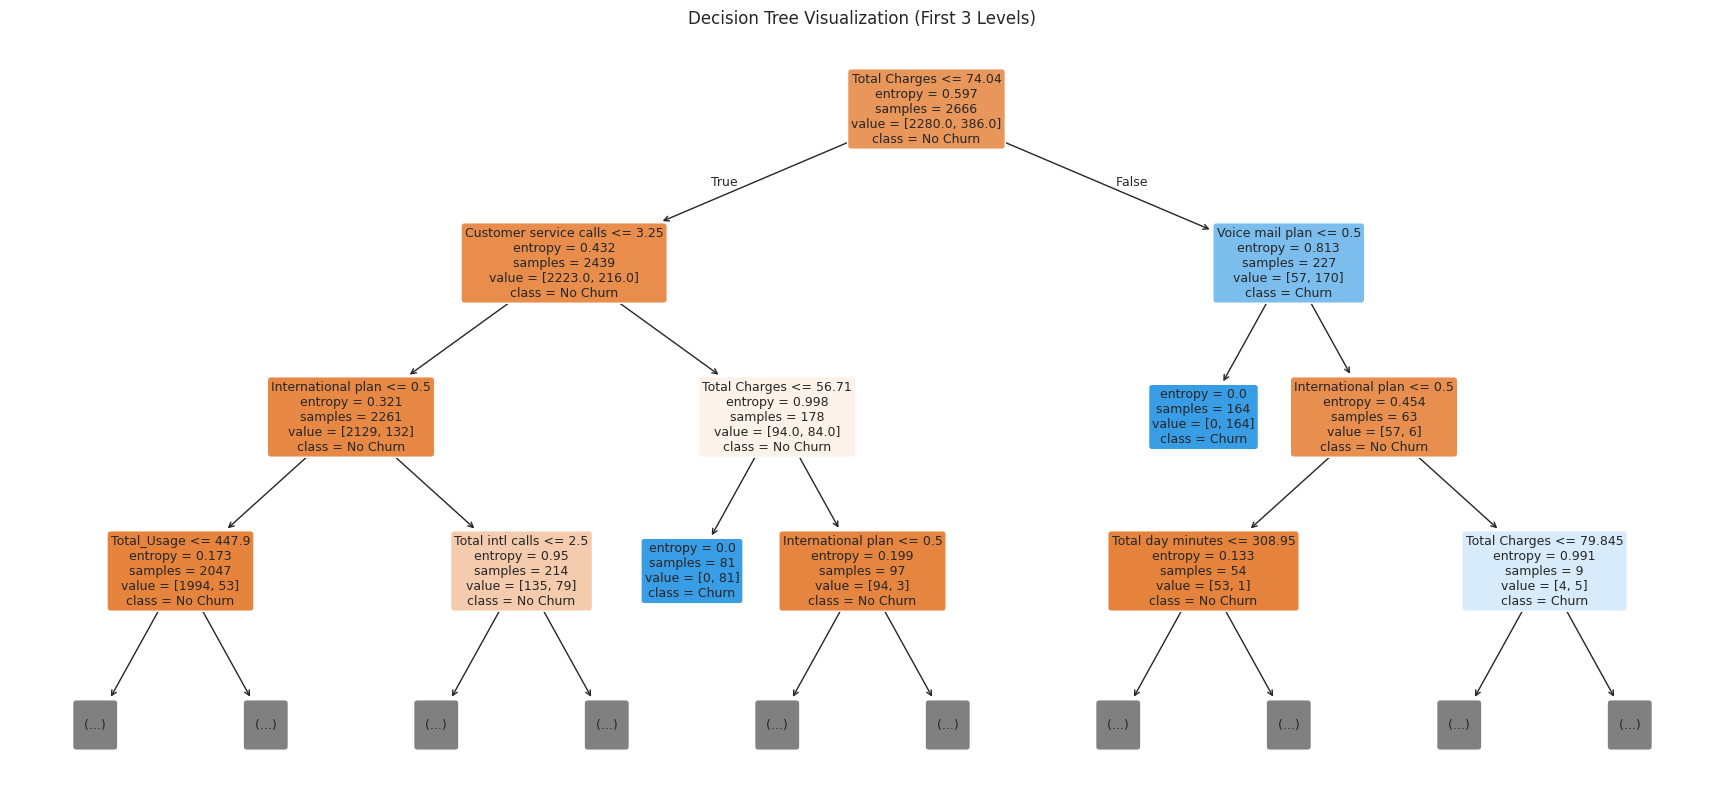

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(22,10))

plot_tree(
    best_dt,
    feature_names=X_train.columns,
    class_names=["No Churn","Churn"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)

plt.title("Decision Tree Visualization (First 3 Levels)")
plt.show()

# Machine Learning Pipeline

Until now, every preprocessing step was performed manually.

- Missing Value Handling
- Encoding
- Feature Scaling
- Model Training

In production, these steps are combined into a single Pipeline.

A Pipeline ensures that every new input passes through the exact same preprocessing steps before reaching the trained model.

Advantages:

- Cleaner Code
- Less Human Error
- Easier Deployment
- Consistent Predictions

In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", DecisionTreeClassifier(**grid_search.best_params_, random_state=42))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 DecisionTreeClassifier(criterion='entropy', max_depth=5,
                                        min_samples_leaf=4, random_state=42))])

# Model Serialization

Training a Machine Learning model can take significant time.

Instead of training the model every time the application starts, we save the trained model to disk.

This process is called **Model Serialization**.

The saved model can later be loaded and used directly for making predictions without retraining.

In Scikit-Learn, the Joblib library is commonly used for model serialization.

In [ ]:
joblib.dump(pipeline, "best_model.pkl")
print("Pipeline saved successfully.")

Pipeline saved successfully.


# Loading the Saved Model

Once the model has been saved, it can be loaded back into memory whenever predictions are required.

This avoids retraining and significantly reduces deployment time.

In [ ]:
loaded_pipeline = joblib.load("best_model.pkl")
print("Pipeline loaded successfully.")

Pipeline loaded successfully.


# Model Inference

Training is the process where the model learns from historical data.

Inference is the process of using the trained model to make predictions on new, unseen data.

During deployment, only inference takes place.

In [ ]:
sample_customer = X_test.iloc[[0]]

prediction = loaded_pipeline.predict(sample_customer)
probability = loaded_pipeline.predict_proba(sample_customer)

print("Prediction :", prediction[0])
print("Prediction Probabilities :", probability)

Prediction : 1
Prediction Probabilities : [[0. 1.]]


In [ ]:
sample_customer = X_test.iloc[[0]]

display(sample_customer)

prediction = loaded_pipeline.predict(sample_customer)

if prediction[0] == 1:
    print("⚠️ Customer is likely to Churn")
else:
    print("✅ Customer is likely to Stay")

,Account length,International plan,Voice mail plan,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,...,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY,Revenue_Segment_Medium,Revenue_Segment_High
717,161.0,0,0,191.9,113.0,70.9,87.0,204.8,107,13.4,...,0,0,0,0,0,0,1,0,0,0


⚠️ Customer is likely to Churn


# AI Assisted Deployment

Modern Machine Learning Engineers use AI coding assistants such as:

- ChatGPT
- Claude
- GitHub Copilot

These tools accelerate application development.

Our next step is to integrate the trained pipeline into a professional Streamlit application.

# Prompt for AI

You are a Senior Machine Learning Engineer.

I have a trained Decision Tree Pipeline saved as **best_model.pkl**.

Create a professional Streamlit application with:

- Modern UI
- Sidebar
- Customer Input Form
- Predict Button
- Prediction Probability
- Error Handling
- Download Prediction
- Professional Styling

# Production Project Structure

Customer_Churn_Project/

│

├── app.py

├── best_model.pkl

├── requirements.txt

├── README.md

├── customer_data.csv

└── notebook.ipynb